# Measures of Lexical Distinctiveness, Similarity, and Syntactic Complexity

In [1]:
# packages
import duckdb
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Load Data

In [2]:
con = duckdb.connect("../guardian_articles.duckdb")
df = con.execute("SELECT * FROM sample_articles").fetchdf()

In [4]:
df.head()

,id,type,sectionId,sectionName,webPublicationDate,webTitle,webUrl,apiUrl,body,isHosted,pillarId,pillarName,headline,shortUrl,search_term,pull_date,clean_body,rn
0,uk-news/2019/mar/15/hillsborough-disaster-lawy...,article,uk-news,UK news,2019-03-15 19:15:37,Hillsborough lawyer calls prosecution 'breatht...,https://www.theguardian.com/uk-news/2019/mar/1...,https://content.guardianapis.com/uk-news/2019/...,<p>The barrister defending the former South Yo...,False,pillar/news,News,Hillsborough lawyer calls prosecution 'breatht...,https://www.theguardian.com/p/b29a3,artificial intelligence,2026-02-22 21:17:05.368877,The barrister defending the former South Yorks...,1
1,football/2025/aug/28/goalless-draw-earns-cryst...,article,football,Football,2025-08-28 19:39:40,Goalless draw earns Crystal Palace aggregate w...,https://www.theguardian.com/football/2025/aug/...,https://content.guardianapis.com/football/2025...,<p>Crystal Palace’s European adventure goes on...,False,pillar/sport,Sport,Goalless draw earns Crystal Palace aggregate w...,https://www.theguardian.com/p/x34dcq,artificial intelligence,2026-02-22 21:17:05.346363,Crystal Palace’s European adventure goes on af...,2
2,commentisfree/2017/jan/12/the-guardian-view-on...,article,commentisfree,Opinion,2017-01-12 19:17:22,The Guardian view on Trump on the eve: democra...,https://www.theguardian.com/commentisfree/2017...,https://content.guardianapis.com/commentisfree...,"<p>If a <a href=""https://www.theguardian.com/u...",False,pillar/opinion,Opinion,The Guardian view on Trump on the eve: democra...,https://www.theguardian.com/p/5kme5,artificial intelligence,2026-02-22 21:17:05.376037,If a one-hour press conference is anything to ...,3
3,us-news/2018/mar/12/trump-russia-investigation...,article,us-news,US news,2018-03-12 23:38:07,House committee led by Trump ally says campaig...,https://www.theguardian.com/us-news/2018/mar/1...,https://content.guardianapis.com/us-news/2018/...,<p>A congressional committee led by a member o...,False,pillar/news,News,House committee led by Trump ally says campaig...,https://www.theguardian.com/p/89xe6,artificial intelligence,2026-02-22 21:17:05.371550,A congressional committee led by a member of D...,4
4,politics/2020/feb/18/no-10-under-pressure-andr...,article,politics,Politics,2020-02-18 19:44:37,No 10 under pressure to say whether it vetted ...,https://www.theguardian.com/politics/2020/feb/...,https://content.guardianapis.com/politics/2020...,<p>Downing Street has come under intense press...,False,pillar/news,News,No 10 under pressure to say whether it vetted ...,https://www.theguardian.com/p/dac6a,artificial intelligence,2026-02-22 21:17:05.366460,Downing Street has come under intense pressure...,5


In [18]:
df.columns

Index(['id', 'type', 'sectionId', 'sectionName', 'webPublicationDate',
       'webTitle', 'webUrl', 'apiUrl', 'body', 'isHosted', 'pillarId',
       'pillarName', 'headline', 'shortUrl', 'search_term', 'pull_date',
       'clean_body', 'rn'],
      dtype='object')

# Pre-processing
- Creating a short_id that is alphanumeric

In [19]:
# creating "short_id"
import pandas as pd

# make sure sorted in a deterministic way
df = df.sort_values(["sectionId", "webPublicationDate"])

# rank within each section
df["section_rank"] = df.groupby("sectionId").cumcount() + 1

# convert rank to A01 format
df["short_code"] = "A" + df["section_rank"].astype(str).str.zfill(2)

# combine with sectionId
df["short_id"] = df["sectionId"] + "-" + df["short_code"]

# optional: drop helper columns
df = df.drop(columns=["section_rank", "short_code"])

print(df[["sectionId", "short_id"]].head())

         sectionId            short_id
15  australia-news  australia-news-A01
10           books           books-A01
2    commentisfree   commentisfree-A01
12     environment     environment-A01
7      environment     environment-A02


# TF-IDF

Top TF-IDF Terms by document plot for all articles in sample_articles

In [23]:
# computing TF-IDF
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.9, min_df=1)

tfidf_matrix = vectorizer.fit_transform(df["body"])

# Convert to DataFrame for easier inspection
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=df["short_id"],
)

print(tfidf_df.shape)

(20, 8560)


# Pearson Correlation

Pairwise Pearson Correlation Between Documents Plot

In [26]:
# compute correlation across documents
correlation_matrix = tfidf_df.T.corr(method="pearson")

# print(correlation_matrix.head())

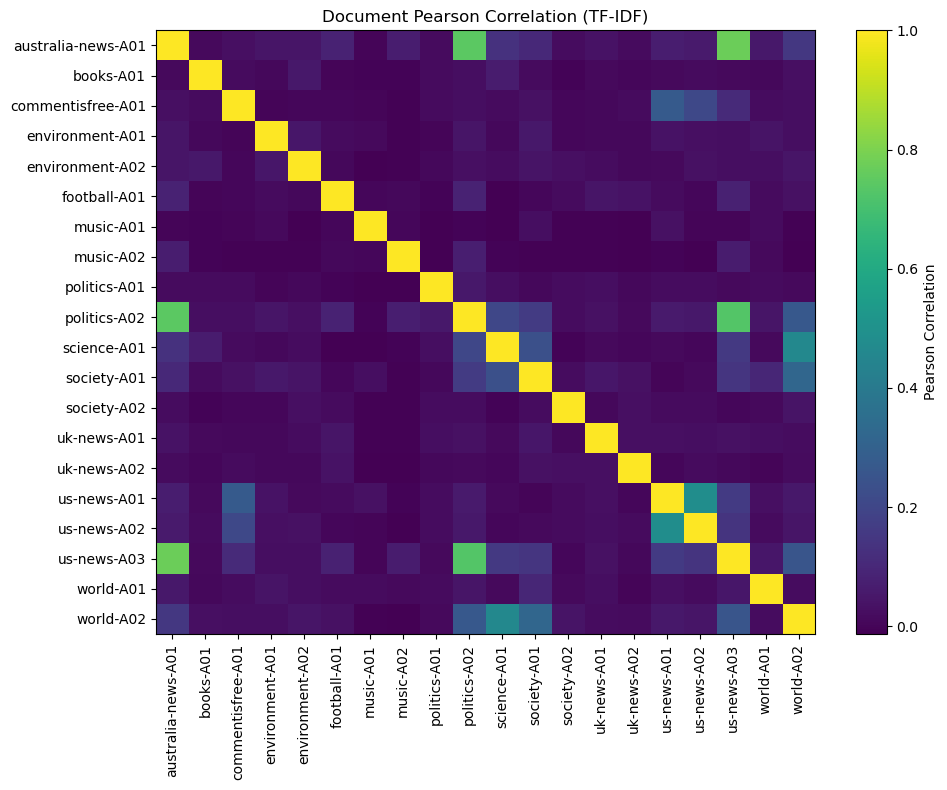

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

corr = correlation_matrix.astype(float)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr.values, aspect="auto")

# Colorbar
cbar = plt.colorbar(im)
cbar.set_label("Pearson Correlation")

# Axis labels
labels = corr.index.astype(str)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))

ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels)

ax.set_title("Document Pearson Correlation (TF-IDF)")
plt.tight_layout()
plt.show()

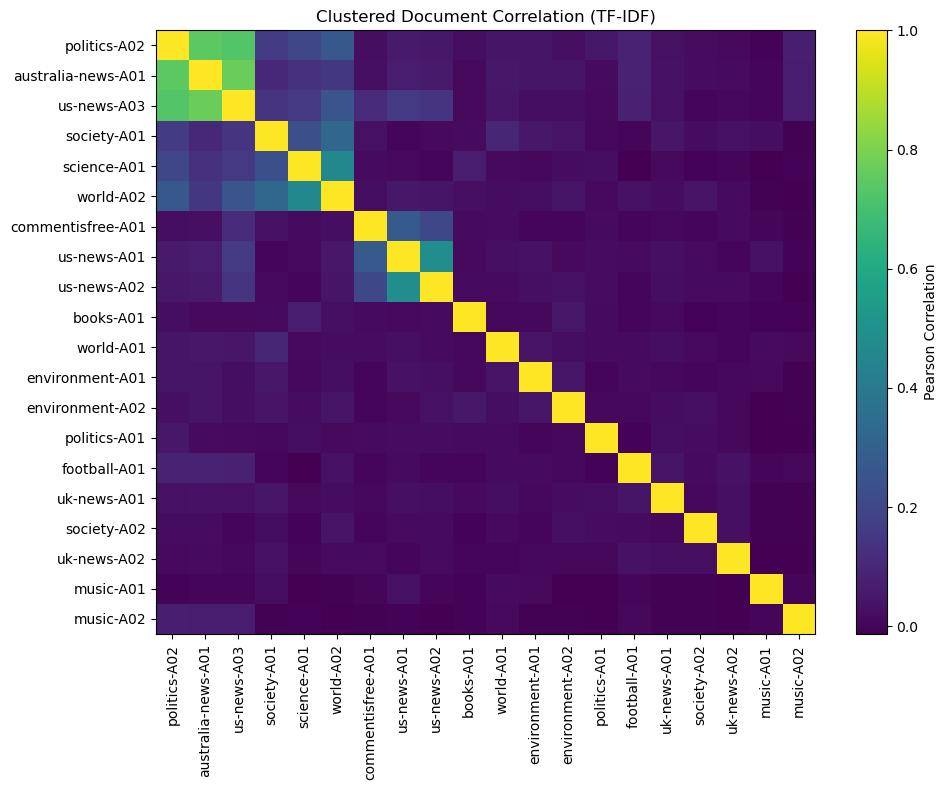

In [ ]:
from scipy.cluster.hierarchy import linkage, leaves_list

# Hierarchical clustering
linked = linkage(corr, method="average")
order = leaves_list(linked)

corr_sorted = corr.iloc[order, order]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_sorted.values, aspect="auto")

plt.colorbar(im).set_label("Pearson Correlation")

sorted_labels = corr_sorted.index.astype(str)

ax.set_xticks(np.arange(len(sorted_labels)))
ax.set_yticks(np.arange(len(sorted_labels)))

ax.set_xticklabels(sorted_labels, rotation=90)
ax.set_yticklabels(sorted_labels)

ax.set_title("Clustered Document Correlation (TF-IDF)")
plt.tight_layout()
plt.show()

# Syntactic Complexity Measures

- could calculate the list of top 30 words ranked by cosine similarity to "artificial intelligence" and "generative AI"
- mean sentence length
- dependent clause density
- clauses per sentence
- dependent clauses per clause/sentence
- coordination per clause/sentence
- complex nominals per clause/sentence


In [32]:
# load model
import spacy
import pandas as pd
import numpy as np

nlp = spacy.load("en_core_web_sm")


In [33]:
def compute_syntactic_profile(text, doc_label="doc"):

    doc = nlp(text)

    sentence_stats = []

    for sent in doc.sents:
        tokens = list(sent)

        token_count = len(tokens)

        # Clause approximation: verbs + auxiliaries
        clauses = sum(1 for t in tokens if t.pos_ in ["VERB", "AUX"])

        # Dependent clauses approximation
        dep_clauses = sum(
            1 for t in tokens if t.dep_ in ["advcl", "ccomp", "xcomp", "acl", "relcl"]
        )

        # Coordination
        coord = sum(1 for t in tokens if t.dep_ == "cc")

        # Complex nominals
        complex_nominals = sum(
            1 for t in tokens if t.dep_ in ["compound", "amod", "nmod", "appos"]
        )

        sentence_stats.append(
            {
                "tokens": token_count,
                "clauses": clauses,
                "dep_clauses": dep_clauses,
                "coord": coord,
                "complex_nominals": complex_nominals,
                "text": sent.text,
            }
        )

    sent_df = pd.DataFrame(sentence_stats)

    if len(sent_df) == 0:
        return None

    MLS = sent_df["tokens"].mean()

    total_sent = len(sent_df)
    total_clauses = sent_df["clauses"].sum()

    if total_clauses == 0:
        total_clauses = np.nan

    C_per_S = sent_df["clauses"].mean()

    DC_per_C = sent_df["dep_clauses"].sum() / total_clauses
    DC_per_S = sent_df["dep_clauses"].sum() / total_sent

    Coord_per_C = sent_df["coord"].sum() / total_clauses
    Coord_per_S = sent_df["coord"].sum() / total_sent

    CN_per_C = sent_df["complex_nominals"].sum() / total_clauses
    CN_per_S = sent_df["complex_nominals"].sum() / total_sent

    # Example sentences
    example_hi = sent_df.sort_values(["dep_clauses", "tokens"], ascending=False).iloc[
        0
    ]["text"]

    example_lo = sent_df.sort_values(["dep_clauses", "tokens"], ascending=True).iloc[0][
        "text"
    ]

    profile = pd.DataFrame(
        [
            {
                "doc": doc_label,
                "MLS": MLS,
                "Clauses_per_Sentence": C_per_S,
                "Dep_Clauses_per_Clause": DC_per_C,
                "Dep_Clauses_per_Sentence": DC_per_S,
                "Coord_per_Clause": Coord_per_C,
                "Coord_per_Sentence": Coord_per_S,
                "Complex_Nominals_per_Clause": CN_per_C,
                "Complex_Nominals_per_Sentence": CN_per_S,
                "example_sentence_high_dep": example_hi,
                "example_sentence_low_dep": example_lo,
            }
        ]
    )

    return profile, sent_df

In [34]:
profiles = []

for _, row in df.iterrows():
    profile, _ = compute_syntactic_profile(row["clean_body"], doc_label=row["short_id"])
    profiles.append(profile)

syntactic_table = pd.concat(profiles, ignore_index=True)

print(syntactic_table.head())

                  doc        MLS  Clauses_per_Sentence  \
0  australia-news-A01  25.190736              4.158038   
1           books-A01  27.282609              3.782609   
2   commentisfree-A01  26.187500              4.593750   
3     environment-A01  28.943396              4.735849   
4     environment-A02  28.718750              4.250000   

   Dep_Clauses_per_Clause  Dep_Clauses_per_Sentence  Coord_per_Clause  \
0                0.374509                  1.557221          0.144168   
1                0.350575                  1.326087          0.327586   
2                0.448980                  2.062500          0.197279   
3                0.450199                  2.132075          0.151394   
4                0.426471                  1.812500          0.227941   

   Coord_per_Sentence  Complex_Nominals_per_Clause  \
0            0.599455                     0.832896   
1            1.239130                     1.086207   
2            0.906250                     0.591837

In [ ]:
# close connection to db
# con.close()